In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
transform=transforms.Compose([transforms.Resize((32,32)), transforms.ToTensor()])
dataset=ImageFolder(
    root="GTSRB/Train",
    transform=transform)
print("dataset size is ", len(dataset))
print("Classes:", len(dataset.classes))

dataset size is  39209
Classes: 43


In [5]:
trainsize=int(0.8*len(dataset))
valsize=len(dataset)- trainsize
traindataset, valdataset=random_split(dataset,[trainsize,valsize])
print("Train:",len(traindataset))
print("Validation:",len(valdataset))

Train: 31367
Validation: 7842


In [7]:
batch_size=64
train_loader=DataLoader(
    traindataset,
    batch_size=batch_size,
    shuffle=True)
val_loader= DataLoader(
    valdataset,
    batch_size=batch_size
)

print("Train batches:",len(train_loader))
print("Validation batches:",len(val_loader))

Train batches: 491
Validation batches: 123


In [8]:
import torch.nn as nn
class ResidualBlock(nn.Module):
    def __init__(self, in_channels,out_channels, stride=1):
        super().__init__()
        self.conv1=nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 =nn.BatchNorm2d(out_channels)
        self.conv2=nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2=nn.BatchNorm2d(out_channels)
        self.shortcut=nn.Sequential()
        if stride !=1 or in_channels !=out_channels:
            self.shortcut=nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        out=self.conv1(x)
        out=self.bn1(out)
        out=nn.ReLU()(out)
        out=self.conv2(out)
        out=self.bn2(out)
        out+=self.shortcut(x)
        out=nn.ReLU()(out)
        return out
        
        
        

In [9]:
block=ResidualBlock(64,64)
x=torch.randn(1,64,32,32)
y=block(x)
print("Input shape :",x.shape)
print("Output shape:",y.shape)

Input shape : torch.Size([1, 64, 32, 32])
Output shape: torch.Size([1, 64, 32, 32])


In [10]:
class ResNet18(nn.Module):
    def __init__(self,num_classes=43):
        super().__init__()
        self.in_channels=64
        self.conv1=nn.Sequential(
            nn.Conv2d(
                3,
                64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer1=self.make_layer(64,2,stride=1)
        self.layer2=self.make_layer(128, 2,stride=2)
        self.layer3 =self.make_layer(256, 2,stride=2)
        self.layer4=self.make_layer(512,2, stride=2)
        self.avgpool=nn.AdaptiveAvgPool2d((1,1))
        self.fc=nn.Linear(512, num_classes)
    def make_layer(self,out_channels,num_blocks,stride):
        strides=[stride]+[1]*(num_blocks-1)
        lay=[]
        for stride in strides:
            lay.append(
                ResidualBlock(
                    self.in_channels,
                    out_channels,
                    stride
                )
            )
            self.in_channels=out_channels
        return nn.Sequential(*lay)
    def forward(self,x):
        x=self.conv1(x)
        x=self.layer1(x)
        x=self.layer2(x)
        x=self.layer3(x)
        x=self.layer4(x)
        x=self.avgpool(x)
        x=torch.flatten(x,1)
        x=self.fc(x)
        return x
    

In [11]:
model=ResNet18().to(device)
print(model)

ResNet18(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 

In [12]:
images,labels=next(iter(train_loader))
images=images.to(device)
outputs=model(images)
print("Images shape :",images.shape)
print("Outputs shape:",outputs.shape)

Images shape : torch.Size([64, 3, 32, 32])
Outputs shape: torch.Size([64, 43])


In [14]:
#loss func and optimizer
criterion=nn.CrossEntropyLoss()
import torch.optim as optm
optimizer=optm.Adam(
    model.parameters(),
    lr=0.001)

In [15]:
#training loops...
num_epochs=5
trainlosses=[]
vallosses=[]
for epoch in range(num_epochs):
    model.train()
    running_loss=0
    for images,labels in train_loader:
        images=images.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    trainloss=running_loss/len(train_loader)
    trainlosses.append(trainloss)
    model.eval()
    valloss=0
    with torch.no_grad():
        for images,labels in val_loader:
            images=images.to(device)
            labels=labels.to(device)
            outputs=model(images)
            loss=criterion(outputs,labels)
            valloss+=loss.item()
    valloss /=len(val_loader)
    vallosses.append(valloss)
    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {trainloss:.4f} | "
        f"Val Loss: {valloss:.4f}"
    )
    

Epoch 1/5 | Train Loss: 1.2439 | Val Loss: 0.1087
Epoch 2/5 | Train Loss: 0.0702 | Val Loss: 0.0972
Epoch 3/5 | Train Loss: 0.0382 | Val Loss: 0.0829
Epoch 4/5 | Train Loss: 0.0325 | Val Loss: 0.0197
Epoch 5/5 | Train Loss: 0.0175 | Val Loss: 0.0153


In [16]:
c=0
t=0
model.eval()
with torch.no_grad():
    for images,labels in val_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)
        _, predicted=torch.max(outputs,1)
        t+=labels.size(0)
        c+=(predicted==labels).sum().item()
acc=100*c/t
print(f"Validation accuracy:{acc:2f}%")


Validation accuracy:99.553685%


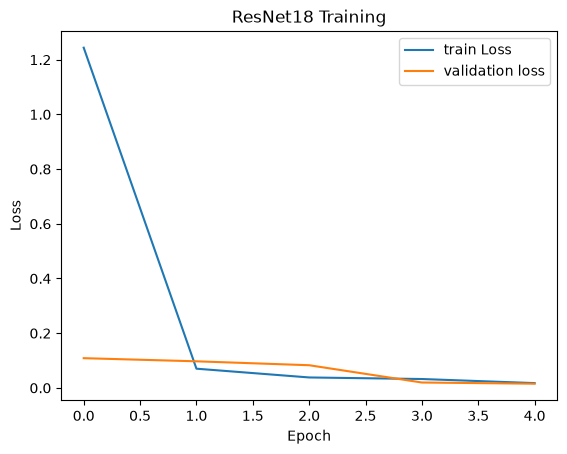

In [17]:
import matplotlib.pyplot as plt
plt.plot(trainlosses,label="train Loss")
plt.plot(vallosses, label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Training")
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

In [19]:
images, labels=next(iter(val_loader))
images=images.to(device)
model.eval()
with torch.no_grad():
    outputs=model(images)
    _, preds=torch.max(outputs, 1)

for i in range(10):
    print(
        f"True: {labels[i].item()} | "
        f"Pred: {preds[i].cpu().item()}")

True: 18 | Pred: 18
True: 10 | Pred: 10
True: 31 | Pred: 31
True: 1 | Pred: 1
True: 31 | Pred: 31
True: 3 | Pred: 3
True: 18 | Pred: 18
True: 4 | Pred: 4
True: 7 | Pred: 7
True: 21 | Pred: 21


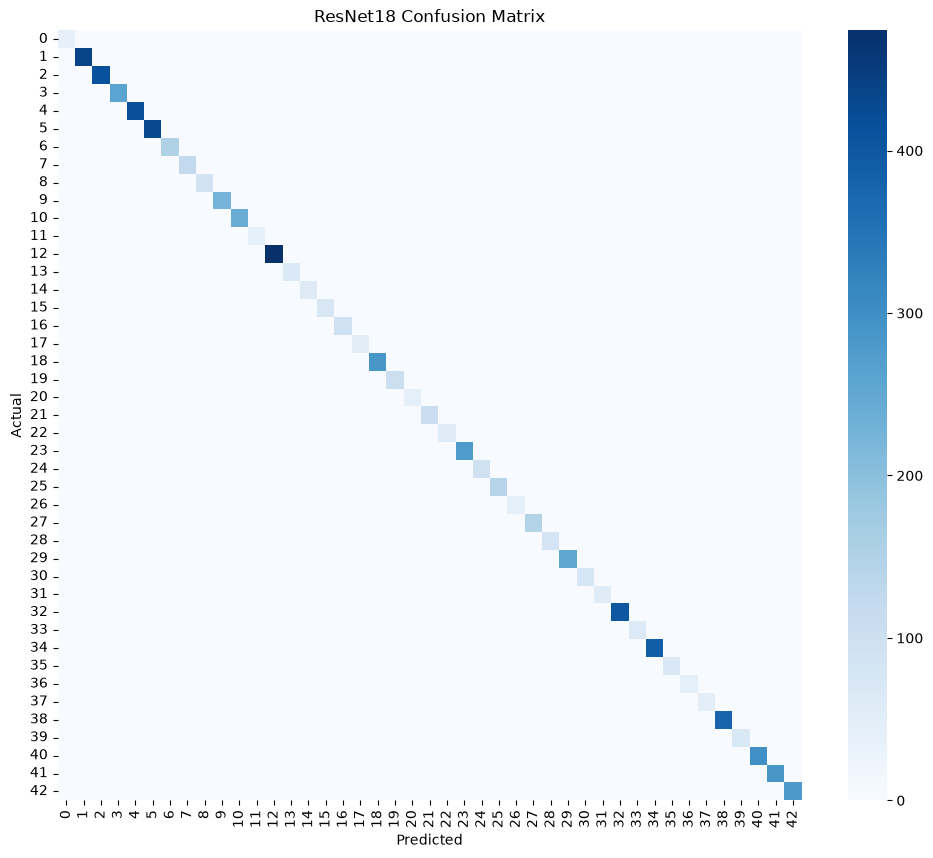

In [22]:
#let us build confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
allpreds=[]
alllabels=[]
model.eval()
with torch.no_grad():
    for images,labels in val_loader:
        images=images.to(device)
        outputs=model(images)
        _, preds=torch.max(outputs, 1)
        allpreds.extend(preds.cpu().numpy())
        alllabels.extend(labels.numpy())
cmatrix=confusion_matrix(alllabels,allpreds)
plt.figure(figsize=(12,10))
sns.heatmap(cmatrix, cmap="Blues")

plt.title("ResNet18 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
images,labels=next(iter(val_loader))
images=images.to(device)
model.eval()
with torch.no_grad():
    outputs=model(images)
    _, preds= torch.max(outputs, 1)
for i in range(10):
    print(
        f"True:{labels[i].item()} "
        f"Pred:{preds[i].cpu().item()}"
    )

True:18 Pred:18
True:10 Pred:10
True:31 Pred:31
True:1 Pred:1
True:31 Pred:31
True:3 Pred:3
True:18 Pred:18
True:4 Pred:4
True:7 Pred:7
True:21 Pred:21


In [24]:
torch.save(
    model.state_dict(),
    "resnet18_task2.pth"
)



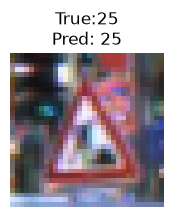

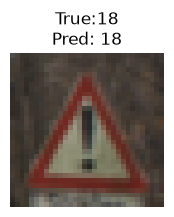

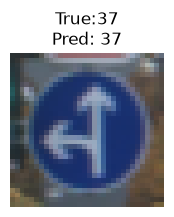

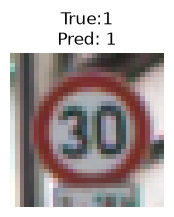

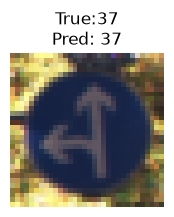

In [25]:
import matplotlib.pyplot as plt
import torch
classes=dataset.dataset.classes if hasattr(dataset, "dataset") else dataset.classes
model.eval()
images,labels=next(iter(val_loader))
images=images.to(device)
with torch.no_grad():
    outputs= model(images)
    _, preds=torch.max(outputs, 1)

for i in range(5):
    plt.figure(figsize=(2,2))

    img=images[i].cpu().permute(1,2,0)

    plt.imshow(img)
    plt.title(
        f"True:{classes[labels[i]]}\nPred: {classes[preds[i]]}"
    )
    plt.axis("off")
    plt.show()